# 02 · Pass 1 — base configurations

Every model is trained **once** with a single fixed configuration on the full training
set, then ranked by test **PR-AUC**. This notebook shows the configurations, then loads
the precomputed results and visualizes the ranking.

In [1]:
# --- make the benchmark/ package importable from notebooks/ ---
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / 'benchmark').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print('project root:', ROOT)

project root: D:\_fcall\UNIFEI\tcc\hpc_workload


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'font.family': 'DejaVu Sans',
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.8,
    'axes.edgecolor': '#c3c2b7', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.labelcolor': '#52514e', 'text.color': '#0b0b0b', 'figure.facecolor': 'white',
})
BLUE, MUTED, BAD, LIGHTBLUE = '#2a78d6', '#898781', '#d03b3b', '#9ec5f4'

In [3]:
import benchmark.config as C
from benchmark.models import get_base_models
import numpy as np, pandas as pd, json

y_train = np.load(C.artifact_path('y_train'))
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
print('scale_pos_weight =', round(scale_pos_weight, 4))

scale_pos_weight = 30.2601


## The 15 models and the exact parameters tested

In [4]:
specs = get_base_models(scale_pos_weight)
tbl = pd.DataFrame([{'#': i + 1, 'model': s.name, 'family': s.family,
                     'scaled': s.needs_scaling, 'configuration': json.dumps(s.params)}
                    for i, s in enumerate(specs)]).set_index('#')
tbl

,model,family,scaled,configuration
#,,,,
1,DummyClassifier,baseline,False,"{""strategy"": ""prior""}"
2,GaussianNB,baseline,True,{}
3,LogisticRegression,linear,True,"{""class_weight"": ""balanced"", ""max_iter"": 2000,..."
4,DecisionTreeClassifier,tree,False,"{""class_weight"": ""balanced"", ""max_depth"": 10}"
5,RandomForestClassifier,forest,False,"{""n_estimators"": 300, ""class_weight"": ""balanced""}"
6,ExtraTreesClassifier,forest,False,"{""n_estimators"": 300, ""class_weight"": ""balanced""}"
7,HistGradientBoostingClassifier,boosting,False,"{""class_weight"": ""balanced"", ""max_iter"": 300}"
8,LightGBM,boosting,False,"{""n_estimators"": 300, ""num_leaves"": 31, ""learn..."
9,XGBoost,boosting,False,"{""n_estimators"": 300, ""max_depth"": 6, ""learnin..."


## Training (gated)

The full training loop lives in `benchmark/run_pass1.py` (each model isolated in
`try/except`, timed, peak-RAM sampled, appended to `results.csv`). It is **gated** here so
opening the notebook costs seconds. Flip `RUN_TRAINING = True` to retrain (~2 h).

In [5]:
RUN_TRAINING = False
if RUN_TRAINING:
    import benchmark.run_pass1 as R1
    R1.run()                     # retrains all 15, rewrites results/results.csv
else:
    print('Loading precomputed results/results.csv  (set RUN_TRAINING=True to retrain).')

Loading precomputed results/results.csv  (set RUN_TRAINING=True to retrain).


## Ranking by test PR-AUC

In [6]:
df = pd.read_csv(C.RESULTS_CSV).drop_duplicates(['model', 'pass'], keep='last')
p1 = df[(df['pass'] == 1) & (df['status'] == 'ok')].sort_values('pr_auc', ascending=False)
p1[['model', 'family', 'pr_auc', 'roc_auc', 'recall_global', 'train_time_s']].reset_index(drop=True)

,model,family,pr_auc,roc_auc,recall_global,train_time_s
0,CatBoost,boosting,0.079467,0.607839,0.495258,211.06
1,LightGBM,boosting,0.079296,0.617776,0.488976,61.20
2,HistGradientBoostingClassifier,boosting,0.075226,0.619694,0.476149,196.41
3,EasyEnsembleClassifier,imbalance,0.070440,0.565873,0.687794,1849.53
4,LogisticRegression,linear,0.062564,0.577335,0.770037,77.90
5,XGBoost,boosting,0.059482,0.603126,0.416692,88.84
6,ExtraTreesClassifier,forest,0.058174,0.577552,0.032377,615.96
7,SGDClassifier,linear,0.057443,0.558854,0.672204,33.75
8,GaussianNB,baseline,0.057205,0.620288,0.206542,3.41
9,BalancedRandomForestClassifier,imbalance,0.056958,0.601697,0.069452,356.65


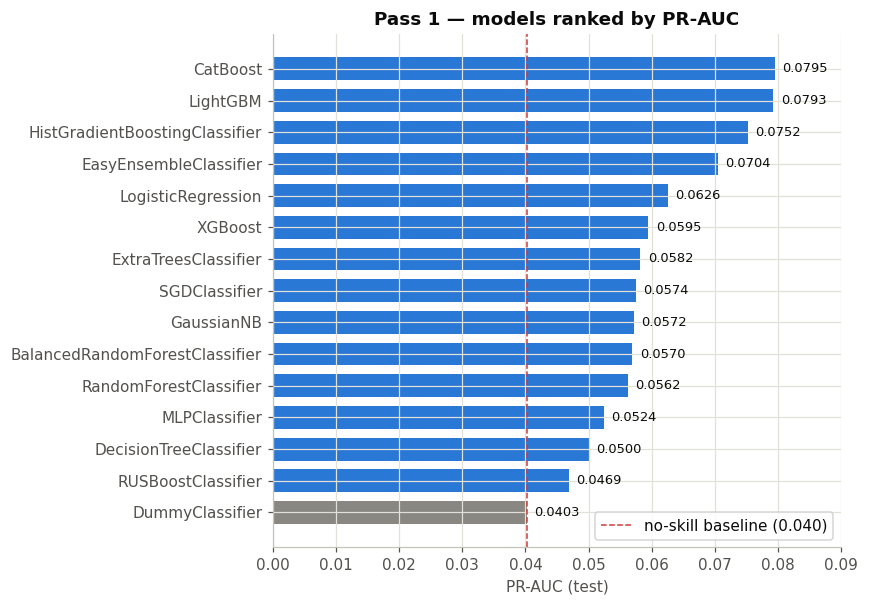

In [7]:
d = p1.sort_values('pr_auc')
base = float(df[(df['pass'] == 1) & (df['model'] == 'DummyClassifier')]['pr_auc'].iloc[0])
colors = [MUTED if m == 'DummyClassifier' else BLUE for m in d['model']]
fig, ax = plt.subplots(figsize=(8, 5.6))
ax.barh(d['model'], d['pr_auc'], color=colors, height=0.72)
ax.axvline(base, color=BAD, ls='--', lw=1, label=f'no-skill baseline ({base:.3f})')
for y, v in enumerate(d['pr_auc']):
    ax.text(v + 0.0012, y, f'{v:.4f}', va='center', fontsize=8.5)
ax.set_xlabel('PR-AUC (test)'); ax.set_xlim(0, 0.09)
ax.set_title('Pass 1 — models ranked by PR-AUC'); ax.legend(loc='lower right')
fig.tight_layout(); plt.show()

**Takeaway.** The three histogram gradient-boosting methods (CatBoost, LightGBM, HGB) lead decisively — the winning family is unambiguous.